<a href="https://colab.research.google.com/github/SAO-P/Basic-Deep-Learning-2026-Spring/blob/main/Lecture1-homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CLIP**

(1)やったこと・動かしたものの概要

CLIPを用いて画像分類を行った。コードはCLIPのGitHubを参考にし、ChatGPTを用いて修正および関数化を行った。また、追加の学習を行わずに、任意のカテゴリ（英語・日本語・具体的・抽象的概念）で分類が可能かを検証した。


(2) 具体的な手続き
Google Colaboratoryを用いて環境構築を行った。

In [ ]:
!pip install transformers torch pillow

from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO
import torch

# load model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# image form internet
url = "https://images.dog.ceo/breeds/husky/n02110185_1469.jpg"
image = Image.open(BytesIO(requests.get(url).content))

# label
labels = ["a dog", "a cat", "a person"]

# 처리
inputs = processor(text=labels, images=image, return_tensors="pt", padding=True)
outputs = model(**inputs)

# result
probs = outputs.logits_per_image.softmax(dim=1)

print(probs)
print("Answer:", labels[probs.argmax()])

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[0.9766, 0.0139, 0.0095]], grad_fn=<SoftmaxBackward0>)
Answer: a dog


tensor([[0.9766, 0.0139, 0.0095]],
Answer: a dog

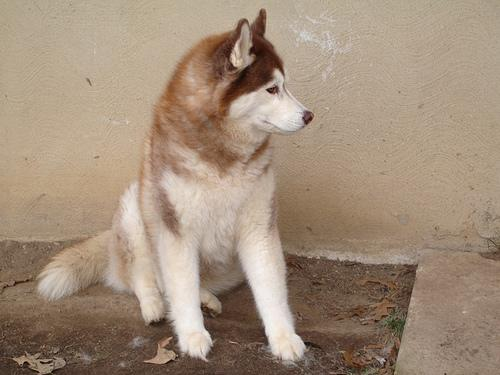

(引用：https://images.dog.ceo/breeds/husky/n02110185_1469.jpg )


CLIPモデルを読み込み、画像とテキストを入力として分類を行う関数を作成した。結果より、正しく犬と分類されたことが確認できた。

In [ ]:
#func
def clip_classify(image, labels):
    inputs = processor(text=labels, images=image, return_tensors="pt", padding=True)
    outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)

    print("Labels:", labels)
    print("Probabilities:", probs.detach().numpy())
    print("Answer:", labels[probs.argmax()])
    print("-" * 40)

画像とテキストラベルを入力として、CLIPによる画像分類を行う関数を定義した。
この関数では、画像とテキストをモデルに入力し、それらの類似度をもとに最も適切なラベルを出力する。

In [ ]:
clip_classify(image, ["a dog", "a cat", "a person"])
clip_classify(image, ["犬", "猫", "人"])
clip_classify(image, ["Golden Retriever", "Poodle", "Bulldog"])
clip_classify(image, ["cute", "scary", "dangerous"])
clip_classify(image, ["Golden Retriever","Husky", "Bulldog"])

Labels: ['a dog', 'a cat', 'a person']
Probabilities: [[0.97655463 0.01390159 0.00954376]]
Answer: a dog
----------------------------------------
Labels: ['犬', '猫', '人']
Probabilities: [[0.98565733 0.00560117 0.00874151]]
Answer: 犬
----------------------------------------
Labels: ['Golden Retriever', 'Poodle', 'Bulldog']
Probabilities: [[0.6262773  0.04181528 0.3319074 ]]
Answer: Golden Retriever
----------------------------------------
Labels: ['cute', 'scary', 'dangerous']
Probabilities: [[0.38069916 0.21887246 0.40042844]]
Answer: dangerous
----------------------------------------
Labels: ['Golden Retriever', 'Husky', 'Bulldog']
Probabilities: [[0.00540452 0.99173135 0.00286422]]
Answer: Husky
----------------------------------------


複数のラベルを用いて画像分類を行った結果、基本的なカテゴリ（dog, cat, person）および日本語ラベルでも正しく分類できることが確認できた。

一方で、犬種の分類では、正解であるHuskyを含まない場合は誤分類が見られたが、ラベルにHuskyを含めると高い確率で正しく分類された。

また、「cute」や「dangerous」などの抽象的なラベルでは確率差が小さく、結果が曖昧になる傾向が見られた。

In [ ]:
clip_classify(image, ["Golden Retriever","허스키", "Bulldog"])

Labels: ['Golden Retriever', '허스키', 'Bulldog']
Probabilities: [[0.6470422  0.01004561 0.34291214]]
Answer: Golden Retriever
----------------------------------------


In [ ]:
clip_classify(image, ["개", "고양이", "사람"])

Labels: ['개', '고양이', '사람']
Probabilities: [[0.023874   0.9586515  0.01747449]]
Answer: 고양이
----------------------------------------


(허스키= Husky 개=dog 고양이=cat 사람=human)

さらに、ラベルに韓国語を用いた場合、正しく分類できない結果が見られた。例えば、「Husky」を韓国語で与えた場合や、「犬・猫・人」を韓国語で表現した場合に誤分類が生じた。

このことから、CLIPは日本語や英語に比べて韓国語に対する精度が低い可能性があると考えられる。

(3) わかったこと・わからなかったこと

・CLIPは英語だけでなく、日本語でも画像分類が可能であることが分かった  
・正解となるカテゴリを含めた場合、そのラベルの確率が非常に高くなることが分かった  
・正解を含まないラベルのみを与えた場合でも、最も近い概念を選択することが分かった  
・犬種のような詳細なカテゴリや、「cute」のような曖昧な概念でも適切に分類できることが分かった
・CLIPは日本語では高い精度で分類できたが、韓国語では場合によって精度が低下する可能性があると考えられる。  

わからなかったこと
・CLIPがどのように画像とテキストを同一の空間に対応付けているのか  
・Contrastive Learningの具体的な仕組み  
・なぜ学習時に存在しないカテゴリでも分類が可能なのか  

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
import nbformat

path = "/content/drive/MyDrive/DL STUDY/MATSUO DL/DL 2026 SPRING/Lecture1-homework"

nb = nbformat.read(path, as_version=4)

# widgets metadata 제거
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, path)